In [5]:
import pandas as pd
import numpy as np
from numpy.linalg import norm
from Bio import SeqIO
from Bio.Data import CodonTable
from Bio.Seq import Seq
from Bio.SeqUtils import seq3
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.transforms import TransformedBbox
import re
from scipy.stats import mannwhitneyu, spearmanr
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.gridspec import GridSpec
from scipy.spatial.distance import pdist, squareform
from scipy.stats import mannwhitneyu, ttest_ind
from scipy.special import logit
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf



#set to true to reverse complement codons in codon table (heatmap part only! fracs have the same trigger in calculate_aa_fracs.py)
REV_COMP = False
GENES = '-'

In [2]:
codon_table = pd.read_csv('../data/codontable_midori_Blattodea.csv', index_col=0)

In [3]:
if REV_COMP == True:
    #reverse complementing
    codons = ['TTT', 'TTC', 'TTA', 'TTG', 'TCT', 'TCC',
           'TCA', 'TCG', 'TAT', 'TAC', 'TGT', 'TGC', 'TGG', 'CTT', 'CTC', 'CTA',
           'CTG', 'CCT', 'CCC', 'CCA', 'CCG', 'CAT', 'CAC', 'CAA', 'CAG', 'CGT',
           'CGC', 'CGA', 'CGG', 'ATT', 'ATC', 'ATA', 'ATG', 'ACT', 'ACC', 'ACA',
           'ACG', 'AAT', 'AAC', 'AAA', 'AAG', 'AGT', 'AGC', 'AGA', 'AGG', 'GTT',
           'GTC', 'GTA', 'GTG', 'GCT', 'GCC', 'GCA', 'GCG', 'GAT', 'GAC', 'GAA',
           'GAG', 'GGT', 'GGC', 'GGA', 'GGG', 'TAA', 'TAG', 'TGA']
    revcomp_codons = {}
    for cod in codons:
        revcomp = Seq(cod).reverse_complement()
        revcomp_codons[cod] = str(revcomp)
    codon_table.rename(columns=revcomp_codons, inplace=True)

In [4]:
codon_table['Gene_name'].unique()

array(['A6', 'A8', 'CO1', 'CO2', 'CO3', 'Cytb', 'ND1', 'ND2', 'ND3',
       'ND4', 'ND4L', 'ND5', 'ND6'], dtype=object)

In [5]:
if GENES == "+":
    genes = ['A6', 'A8', 'CO1', 'CO2', 'CO3', 'Cytb', 'ND2', 'ND3', 'ND6']
    codon_table = codon_table[codon_table['Gene_name'].isin(genes)]
elif GENES == "-":
    genes = ['ND5', 'ND4', 'ND4L', 'ND1']
    codon_table = codon_table[codon_table['Gene_name'].isin(genes)]

In [6]:
codon_table['Gene_name'].unique()

array(['ND1', 'ND4', 'ND4L', 'ND5'], dtype=object)

In [7]:
len(codon_table['Species_name'].unique())

397

In [8]:
len(codon_table[codon_table['Workers'] == 1.0]['Species_name'].unique())

202

In [9]:
len(codon_table[codon_table['Workers'] == 0]['Species_name'].unique())

129

In [10]:
len(codon_table[codon_table['Workers'].isna()]['Species_name'].unique())

66

In [11]:
to_drop = ['Species_name','GenbankID', 'Taxonomy', 'Gene_name',
       'Gene_start_end_and_trend', 'GeneID', 'Aminoacids_from_genbank',
       'Translated_aminoacids_by_Python', 'Not_standart_codons',
       'Wrong_amino_num', 'Wrong_nucl_num', 'wrong_amino_%', 'Sequence',
       'mtDNA_length', 'nA', 'nT', 'nC', 'nG', 'nNA', '%A', '%T', '%C', '%G',
       '%NA', 'neutralA', 'neutralG', 'neutralC', 'neutralT', 'Neutral_count']
codon_table = codon_table.drop(columns=to_drop)

In [12]:
codon_table

,Workers,TTT,TTC,TTA,TTG,TCT,TCC,TCA,TCG,TAT,...,GAT,GAC,GAA,GAG,GGT,GGC,GGA,GGG,TAA,TAG
4589,1.0,43,5,7,33,16,0,2,1,17,...,5,0,0,10,13,1,2,6,0,1
2978,1.0,48,4,17,47,26,0,2,1,25,...,5,0,1,7,21,4,1,5,0,1
4738,1.0,12,0,1,11,6,1,1,0,9,...,1,0,0,2,5,0,0,0,1,0
5030,1.0,65,4,14,52,41,4,1,1,27,...,14,1,4,5,25,5,2,16,0,0
5158,1.0,39,7,13,26,15,1,3,2,18,...,5,0,4,6,14,3,1,5,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3916,0.0,80,2,26,48,42,0,1,3,26,...,17,0,4,5,36,0,2,8,0,0
3073,0.0,50,1,16,30,24,0,0,0,18,...,5,1,0,9,16,0,1,3,0,1
4819,0.0,58,3,28,50,26,1,6,3,22,...,5,0,3,5,28,0,0,4,1,0
4735,0.0,14,0,6,8,6,0,1,0,9,...,2,0,0,3,4,0,0,2,1,0


In [13]:
codon_table.loc[codon_table['Workers'] == 1.0, 'Workers'] = 'Termite'
codon_table.loc[codon_table['Workers'] == 0.0, 'Workers'] = 'Termite'
codon_table['Workers'] = codon_table['Workers'].fillna('Cockroach')
codon_table = codon_table.rename(columns={'Workers':'Species'})

In [14]:
def draw_heat_map_mito(df_heatmap_codon_change_value, df_heatmap_codon_change_name,
                  df_heatmap_codon_change_aa, file_name,
                  cmd=sns.palettes.blend_palette(( '#ffffff10', '#ff0000af'), 6, as_cmap=True), 
                  title='Heatmap'):
    # cmd palette - from white to red
# Three DataFrames on import in function first - with values, second - text in heatmap cells, 
# three - amino acids that are printed on heatmap (the presence of empty cells in the data frame matters)
    fig, ax=plt.subplots(figsize=(18,18))
    # make heatmap on values and annotation is text from second DataFrame
    sns.heatmap(df_heatmap_codon_change_value, annot=df_heatmap_codon_change_name, fmt='', annot_kws={"ha":'left',"size":15}, cmap=cmd)
    # Here I add Amino acids on plot by coordiate
    for y in range(df_heatmap_codon_change_aa.shape[0]):
        for x in range(df_heatmap_codon_change_aa.shape[1]):
            plt.text(x+0.03, y+0.07, df_heatmap_codon_change_aa.iloc[y,x],horizontalalignment='left',verticalalignment='top',color='black',fontsize=25)

    # Label options
    ax.set_yticks(np.arange(0,16,1))
    ax.set_ylabel('First Nucleotide',size=20)
    ax.set_xlabel('Second Nucleotide',size=20)
    ax.set_title(title,size=20)
    ax.set_yticklabels(('', '', 'T', '', '', '', 'C', '', '', '', 'A', '', '', '', 'G', ''), 
        rotation=0, fontsize="30", va="center")
    plt.xticks(fontsize=30)
    # Here I add boxes around the amino acids the coordinates of the beginning are indicated in parentheses 
    # (0, 0) - top left
    # below is the value of the box in width (everywhere 1) and length (how many codons are included in the amino acid)
    ax.add_patch(
         patches.Rectangle(
             (0, 0),
             1.0,
             2.0,
             edgecolor='black',
             fill=False,
             lw=4
         ) )
    ax.add_patch(
         patches.Rectangle(
             (0, 2),
             1.0,
             2.0,
             edgecolor='black',
             fill=False,
             lw=4
         ) )
    ax.add_patch(
         patches.Rectangle(
             (0, 4),
             1.0,
             4.0,
             edgecolor='black',
             fill=False,
             lw=4
         ) )
    ax.add_patch(
         patches.Rectangle(
             (0, 8),
             1.0,
             2.0,
             edgecolor='black',
             fill=False,
             lw=4
         ) )
    ax.add_patch(
         patches.Rectangle(
             (0, 10),
             1.0,
             2.0,
             edgecolor='black',
             fill=False,
             lw=4
         ) )
    ax.add_patch(
         patches.Rectangle(
             (0, 12),
             1.0,
             4.0,
             edgecolor='black',
             fill=False,
             lw=4
         ) )
    ax.add_patch(
         patches.Rectangle(
             (1, 0),
             1.0,
             4.0,
             edgecolor='black',
             fill=False,
             lw=4
         ) )
    ax.add_patch(
         patches.Rectangle(
             (1, 4),
             1.0,
             4.0,
             edgecolor='black',
             fill=False,
             lw=4
         ) )
    ax.add_patch(
         patches.Rectangle(
             (1, 8),
             1.0,
             4.0,
             edgecolor='black',
             fill=False,
             lw=4
         ) )
    ax.add_patch(
         patches.Rectangle(
             (1, 12),
             1.0,
             4.0,
             edgecolor='black',
             fill=False,
             lw=4
         ) )
    ax.add_patch(
         patches.Rectangle(
             (2, 0),
             1.0,
             2.0,
             edgecolor='black',
             fill=False,
             lw=4
         ) )
    ax.add_patch(
         patches.Rectangle(
             (2, 0),
             1.0,
             4.0,
             edgecolor='black',
             fill=False,
             lw=4
         ) )
    ax.add_patch(
         patches.Rectangle(
             (2, 2),
             1.0,
             2.0,
             edgecolor='black',
             fill=False,
             lw=4
         ) )
    ax.add_patch(
         patches.Rectangle(
             (2, 4),
             1.0,
             2.0,
             edgecolor='black',
             fill=False,
             lw=4
         ) )
    ax.add_patch(
         patches.Rectangle(
             (2, 6),
             1.0,
             2.0,
             edgecolor='black',
             fill=False,
             lw=4
         ) )
    ax.add_patch(
         patches.Rectangle(
             (2, 8),
             1.0,
             2.0,
             edgecolor='black',
             fill=False,
             lw=4
         ) )
    ax.add_patch(
         patches.Rectangle(
             (2, 10),
             1.0,
             2.0,
             edgecolor='black',
             fill=False,
             lw=4
         ) )
    ax.add_patch(
         patches.Rectangle(
             (2, 12),
             1.0,
             2.0,
             edgecolor='black',
             fill=False,
             lw=4
         ) )
    ax.add_patch(
         patches.Rectangle(
             (2, 14),
             1.0,
             2.0,
             edgecolor='black',
             fill=False,
             lw=4
         ) )
    ax.add_patch(
         patches.Rectangle(
             (3, 0),
             1.0,
             2.0,
             edgecolor='black',
             fill=False,
             lw=4
         ) )
    ax.add_patch(
         patches.Rectangle(
             (3, 2),
             1.0,
             2.0,
             edgecolor='black',
             fill=False,
             lw=4
         ) )
    ax.add_patch(
         patches.Rectangle(
             (3, 4),
             1.0,
             4.0,
             edgecolor='black',
             fill=False,
             lw=4
         ) )
    ax.add_patch(
         patches.Rectangle(
             (3, 8),
             1.0,
             2.0,
             edgecolor='black',
             fill=False,
             lw=4
         ) )
    ax.add_patch(
         patches.Rectangle(
             (3, 10),
             1.0,
             2.0,
             edgecolor='black',
             fill=False,
             lw=4
         ) )
    ax.add_patch(
         patches.Rectangle(
             (3, 12),
             1.0,
             4.0,
             edgecolor='black',
             fill=False,
             lw=4
         ) )
    plt.show()
    fig.savefig(f'../figures/{file_name}.pdf', dpi=300)

C:\Users\voron\AppData\Local\Temp\ipykernel_30212\211995010.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  table_for_heatmap['for_count'][i] = i
C:\Users\voron\AppData\Local\Temp\ipykernel_30212\211995010.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  table_for_heatmap['for_count'][i+1] = i
C:\Users\voron\AppData\Local\Temp\ipykernel_30212\211995010.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  table_for_heatmap['cod

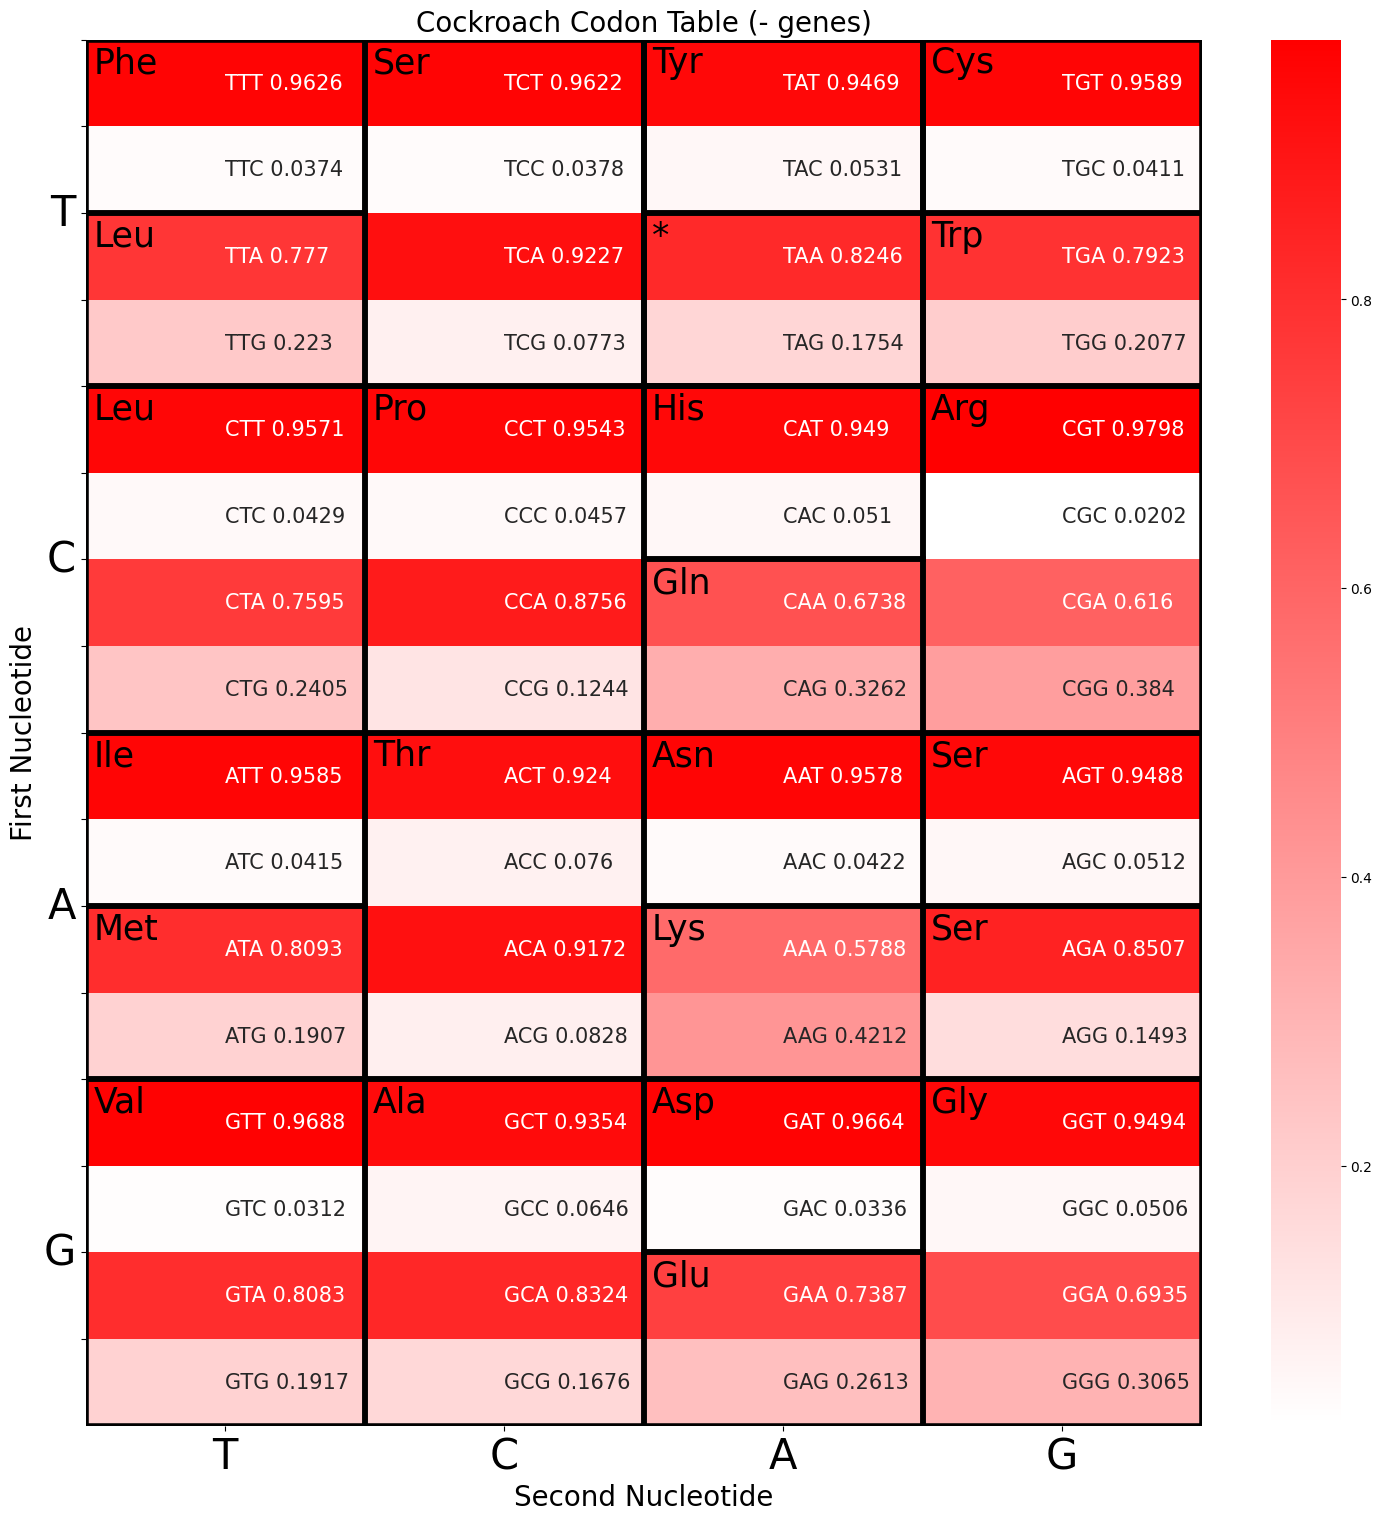

In [15]:
df = codon_table[codon_table['Species'] == 'Cockroach']
df = df.iloc[:, 1:].mean().to_frame().T
df.insert(loc=0, column="Species", value='Cockroach')

# Make list with all codons
codons_t = []
nuc_one = ['A', 'T', 'G', 'C']
nuc_two = ['A', 'T', 'G', 'C']
nuc_three = ['A', 'T', 'G', 'C']
for first in nuc_one:
    for second in nuc_two:
        for three in nuc_three:
            codons_t.append(first+second+three)

# Please, change the name of organism if it is neccessary
organism = 'Cockroach'
name = organism
#Select only organism and codons, tar_ros name comes from original selected species
df_tar_ros = df[df['Species'] == organism][codons_t].reset_index(drop=True)

table_for_heatmap = pd.DataFrame(columns=['codon', 'aa', 'codon_count'])

index_num = 0
for codon in df_tar_ros.columns:
    codon_name = codon
    # Make amino acids from codons
    aa_name = seq3(Seq(codon).translate()[0])
    value = df_tar_ros[codon].sum()
    data = {'codon':codon_name, 'aa':aa_name, 'codon_count':value}
    df = pd.DataFrame(data, index=[index_num])
    table_for_heatmap = pd.concat([df, table_for_heatmap])
    index_num+=1

#small changes to the mitochondrial code, for sure it can be done using biopython, but I'm too lazy to look
table_for_heatmap.loc[table_for_heatmap['codon'] == 'ATA','aa'] = 'Met'
table_for_heatmap.loc[table_for_heatmap['codon'] == 'TGA','aa'] = 'Trp'
table_for_heatmap.loc[table_for_heatmap['codon'] == 'AGA','aa'] = 'Ser'
table_for_heatmap.loc[table_for_heatmap['codon'] == 'AGG','aa'] = 'Ser'

# for sorting by nucleotides levels - TCAG, if you change it - change everywhere in code
table_for_heatmap['first_nucl'] = table_for_heatmap['codon'].astype(str).str[0]
table_for_heatmap['second_nucl'] = table_for_heatmap['codon'].astype(str).str[1]
table_for_heatmap['three_nucl'] = table_for_heatmap['codon'].astype(str).str[2]
table_for_heatmap['first_nucl'] = pd.Categorical(table_for_heatmap['first_nucl'],categories=list('TCAG'))
table_for_heatmap['second_nucl'] = pd.Categorical(table_for_heatmap['second_nucl'],categories=list('TCAG'))
table_for_heatmap['three_nucl'] = pd.Categorical(table_for_heatmap['three_nucl'],categories=list('TCAG'))

# sorting
table_for_heatmap = table_for_heatmap.sort_values(by=['second_nucl','first_nucl','three_nucl']).reset_index(drop=True)

# this is crutch for summing codons that are located nearby, every two codons - one number and after - sum by number
table_for_heatmap['for_count'] = 0
for i in range(0,len(table_for_heatmap),2):
    table_for_heatmap['for_count'][i] = i
    table_for_heatmap['for_count'][i+1] = i

# count fractions of neighboring codons
table_for_heatmap['codon_prop'] = 0.
for index, row in table_for_heatmap.iterrows():
    if table_for_heatmap[table_for_heatmap['for_count'] == table_for_heatmap['for_count'][index]]['codon_count'].sum() != 0:
        table_for_heatmap['codon_prop'][index] = table_for_heatmap['codon_count'][index] / table_for_heatmap[table_for_heatmap['for_count'] == table_for_heatmap['for_count'][index]]['codon_count'].sum()

# make three different DF for heatmap
c_value = list(table_for_heatmap[table_for_heatmap['second_nucl'] == 'C']['codon_prop'])
u_value = list(table_for_heatmap[table_for_heatmap['second_nucl'] == 'T']['codon_prop'])
g_value = list(table_for_heatmap[table_for_heatmap['second_nucl'] == 'G']['codon_prop'])
a_value = list(table_for_heatmap[table_for_heatmap['second_nucl'] == 'A']['codon_prop'])
df_heatmap_codon_change_value = pd.DataFrame({'T':u_value, 'C':c_value, 'A':a_value, 'G':g_value})

name_df = table_for_heatmap[['codon', 'aa', 'codon_prop', 'second_nucl']]
name_df.loc[name_df.duplicated('aa'), 'aa'] = ''
name_df.loc[name_df['codon'] == 'CTT','aa'] = 'Leu'
name_df.loc[name_df['codon'] == 'AGT','aa'] = 'Ser'
name_df.loc[name_df['codon'] == 'AGA','aa'] = 'Ser'
name_df.loc[name_df['codon'] == 'TAA','aa'] = '*'
name_df['codon_prop'] = round(name_df['codon_prop'],4).astype('str')
name_df['summ_info'] = name_df['codon'] + ' ' + name_df['codon_prop']
c_name = list(name_df[name_df['second_nucl'] == 'C']['summ_info'])
u_name = list(name_df[name_df['second_nucl'] == 'T']['summ_info'])
g_name = list(name_df[name_df['second_nucl'] == 'G']['summ_info'])
a_name = list(name_df[name_df['second_nucl'] == 'A']['summ_info'])
df_heatmap_codon_change_name = pd.DataFrame({'T':u_name, 'C':c_name, 'A':a_name, 'G':g_name})

c_aa = list(name_df[name_df['second_nucl'] == 'C']['aa'])
u_aa = list(name_df[name_df['second_nucl'] == 'T']['aa'])
g_aa = list(name_df[name_df['second_nucl'] == 'G']['aa'])
a_aa = list(name_df[name_df['second_nucl'] == 'A']['aa'])
df_heatmap_codon_change_aa = pd.DataFrame({'T':u_aa, 'C':c_aa, 'A':a_aa, 'G':g_aa})

cock_table_for_heatmap = table_for_heatmap

#call function for drawing
draw_heat_map_mito(df_heatmap_codon_change_value, df_heatmap_codon_change_name,
              df_heatmap_codon_change_aa, "codo_usage_cocroach_-.pdf", title=f'{name} Codon Table (- genes)')

C:\Users\voron\AppData\Local\Temp\ipykernel_30212\129353081.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  table_for_heatmap['for_count'][i] = i
C:\Users\voron\AppData\Local\Temp\ipykernel_30212\129353081.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  table_for_heatmap['for_count'][i+1] = i
C:\Users\voron\AppData\Local\Temp\ipykernel_30212\129353081.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  table_for_heatmap['cod

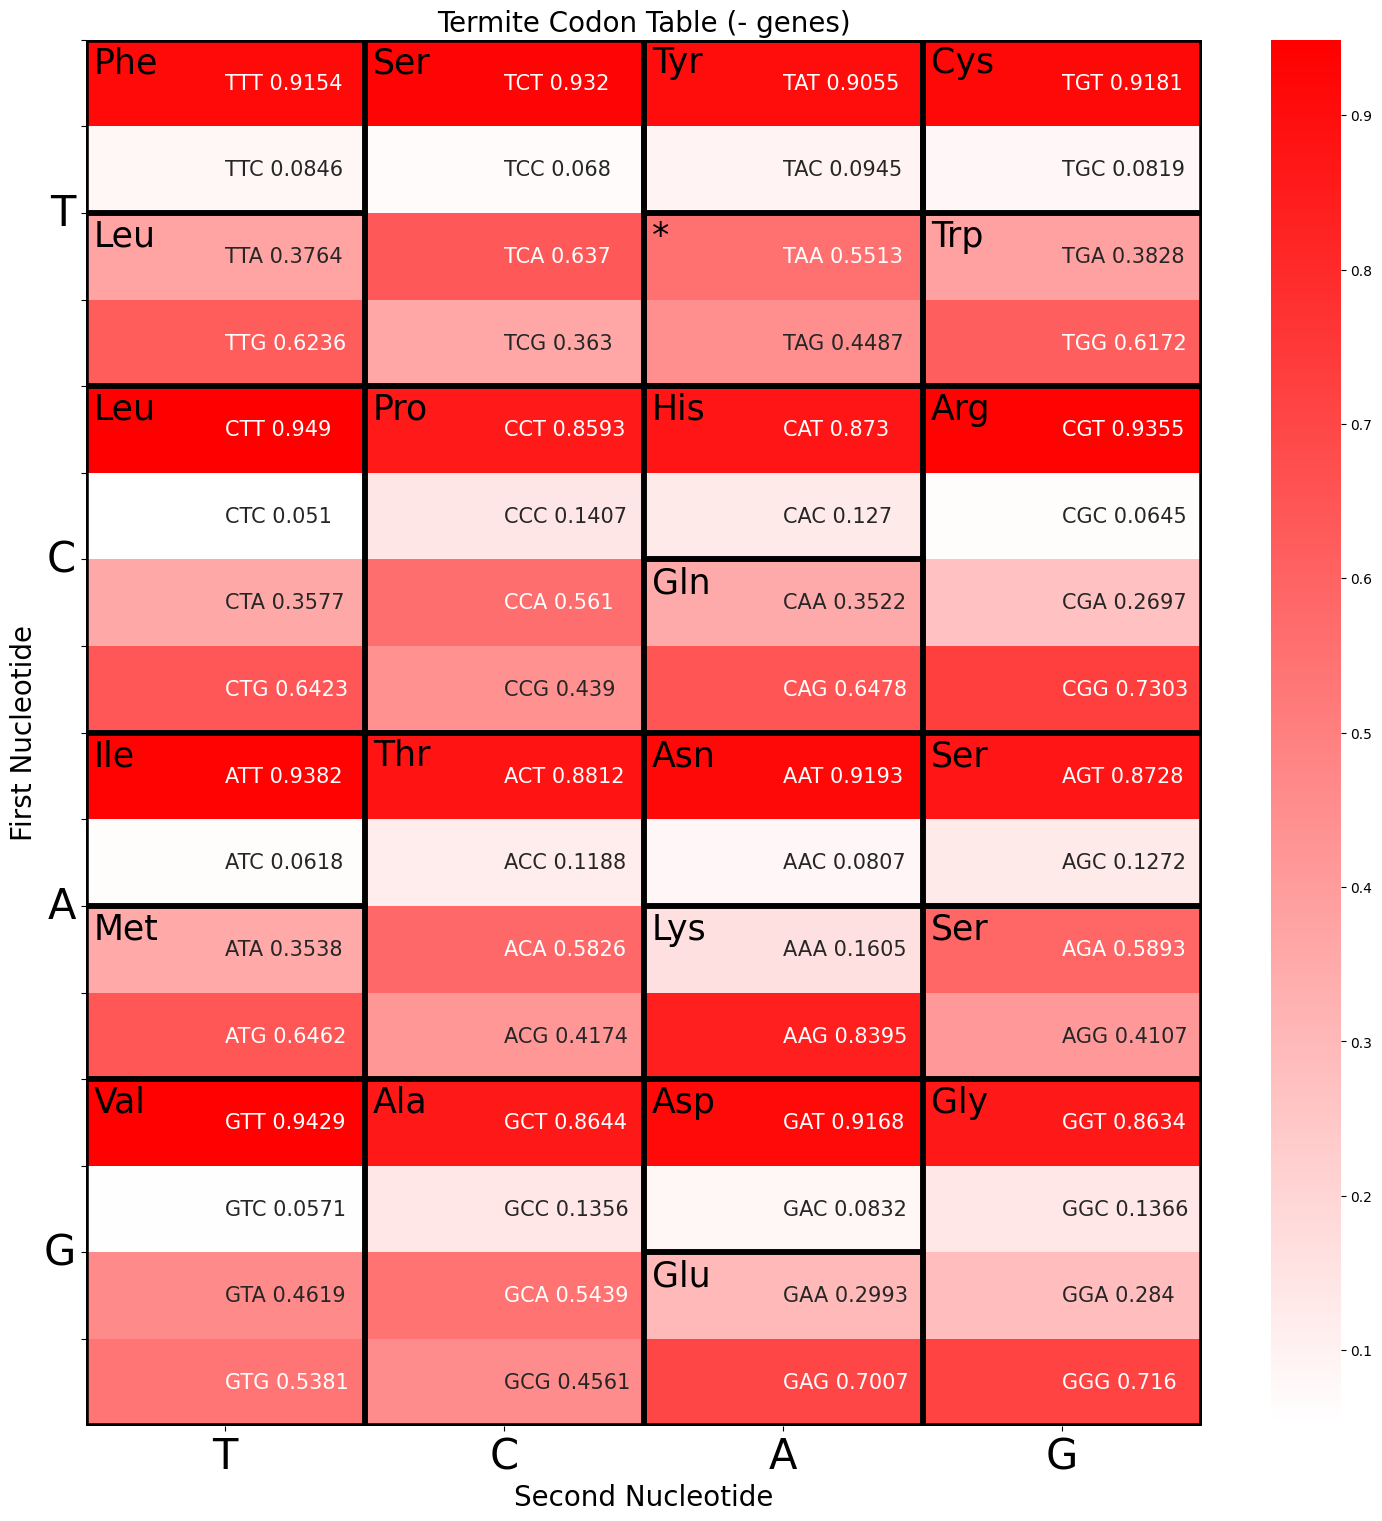

In [16]:
df = codon_table[codon_table['Species'] == 'Termite']
df = df.iloc[:, 1:].mean().to_frame().T
df.insert(loc=0, column="Species", value='Termite')

# Make list with all codons
codons_t = []
nuc_one = ['A', 'T', 'G', 'C']
nuc_two = ['A', 'T', 'G', 'C']
nuc_three = ['A', 'T', 'G', 'C']
for first in nuc_one:
    for second in nuc_two:
        for three in nuc_three:
            codons_t.append(first+second+three)

# Please, change the name of organism if it is neccessary
organism = 'Termite'
name = organism
#Select only organism and codons, tar_ros name comes from original selected species
df_tar_ros = df[df['Species'] == organism][codons_t].reset_index(drop=True)

table_for_heatmap = pd.DataFrame(columns=['codon', 'aa', 'codon_count'])

index_num = 0
for codon in df_tar_ros.columns:
    codon_name = codon
    # Make amino acids from codons
    aa_name = seq3(Seq(codon).translate()[0])
    value = df_tar_ros[codon].sum()
    data = {'codon':codon_name, 'aa':aa_name, 'codon_count':value}
    df = pd.DataFrame(data, index=[index_num])
    table_for_heatmap = pd.concat([df, table_for_heatmap])
    index_num+=1

#small changes to the mitochondrial code, for sure it can be done using biopython, but I'm too lazy to look
table_for_heatmap.loc[table_for_heatmap['codon'] == 'ATA','aa'] = 'Met'
table_for_heatmap.loc[table_for_heatmap['codon'] == 'TGA','aa'] = 'Trp'
table_for_heatmap.loc[table_for_heatmap['codon'] == 'AGA','aa'] = 'Ser'
table_for_heatmap.loc[table_for_heatmap['codon'] == 'AGG','aa'] = 'Ser'

# for sorting by nucleotides levels - TCAG, if you change it - change everywhere in code
table_for_heatmap['first_nucl'] = table_for_heatmap['codon'].astype(str).str[0]
table_for_heatmap['second_nucl'] = table_for_heatmap['codon'].astype(str).str[1]
table_for_heatmap['three_nucl'] = table_for_heatmap['codon'].astype(str).str[2]
table_for_heatmap['first_nucl'] = pd.Categorical(table_for_heatmap['first_nucl'],categories=list('TCAG'))
table_for_heatmap['second_nucl'] = pd.Categorical(table_for_heatmap['second_nucl'],categories=list('TCAG'))
table_for_heatmap['three_nucl'] = pd.Categorical(table_for_heatmap['three_nucl'],categories=list('TCAG'))

# sorting
table_for_heatmap = table_for_heatmap.sort_values(by=['second_nucl','first_nucl','three_nucl']).reset_index(drop=True)

# this is crutch for summing codons that are located nearby, every two codons - one number and after - sum by number
table_for_heatmap['for_count'] = 0
for i in range(0,len(table_for_heatmap),2):
    table_for_heatmap['for_count'][i] = i
    table_for_heatmap['for_count'][i+1] = i

# count fractions of neighboring codons
table_for_heatmap['codon_prop'] = 0.
for index, row in table_for_heatmap.iterrows():
    if table_for_heatmap[table_for_heatmap['for_count'] == table_for_heatmap['for_count'][index]]['codon_count'].sum() != 0:
        table_for_heatmap['codon_prop'][index] = table_for_heatmap['codon_count'][index] / table_for_heatmap[table_for_heatmap['for_count'] == table_for_heatmap['for_count'][index]]['codon_count'].sum()

# make three different DF for heatmap
c_value = list(table_for_heatmap[table_for_heatmap['second_nucl'] == 'C']['codon_prop'])
u_value = list(table_for_heatmap[table_for_heatmap['second_nucl'] == 'T']['codon_prop'])
g_value = list(table_for_heatmap[table_for_heatmap['second_nucl'] == 'G']['codon_prop'])
a_value = list(table_for_heatmap[table_for_heatmap['second_nucl'] == 'A']['codon_prop'])
df_heatmap_codon_change_value = pd.DataFrame({'T':u_value, 'C':c_value, 'A':a_value, 'G':g_value})

name_df = table_for_heatmap[['codon', 'aa', 'codon_prop', 'second_nucl']]
name_df.loc[name_df.duplicated('aa'), 'aa'] = ''
name_df.loc[name_df['codon'] == 'CTT','aa'] = 'Leu'
name_df.loc[name_df['codon'] == 'AGT','aa'] = 'Ser'
name_df.loc[name_df['codon'] == 'AGA','aa'] = 'Ser'
name_df.loc[name_df['codon'] == 'TAA','aa'] = '*'
name_df['codon_prop'] = round(name_df['codon_prop'],4).astype('str')
name_df['summ_info'] = name_df['codon'] + ' ' + name_df['codon_prop']
c_name = list(name_df[name_df['second_nucl'] == 'C']['summ_info'])
u_name = list(name_df[name_df['second_nucl'] == 'T']['summ_info'])
g_name = list(name_df[name_df['second_nucl'] == 'G']['summ_info'])
a_name = list(name_df[name_df['second_nucl'] == 'A']['summ_info'])
df_heatmap_codon_change_name = pd.DataFrame({'T':u_name, 'C':c_name, 'A':a_name, 'G':g_name})

c_aa = list(name_df[name_df['second_nucl'] == 'C']['aa'])
u_aa = list(name_df[name_df['second_nucl'] == 'T']['aa'])
g_aa = list(name_df[name_df['second_nucl'] == 'G']['aa'])
a_aa = list(name_df[name_df['second_nucl'] == 'A']['aa'])
df_heatmap_codon_change_aa = pd.DataFrame({'T':u_aa, 'C':c_aa, 'A':a_aa, 'G':g_aa})

ter_table_for_heatmap = table_for_heatmap

#call function for drawing
draw_heat_map_mito(df_heatmap_codon_change_value, df_heatmap_codon_change_name, 
              df_heatmap_codon_change_aa, "codo_usage_termite_-.pdf", title=f'{name} Codon Table (- genes)')
plt.rcParams["figure.figsize"] = (15,8)

In [116]:
codon_table = pd.read_csv('../data/codontable_midori_Blattodea.csv', index_col=0)
codon_table.loc[codon_table['Workers'] == 1.0, 'Workers'] = 'Termite'
codon_table.loc[codon_table['Workers'] == 0.0, 'Workers'] = 'Termite'
codon_table['Workers'] = codon_table['Workers'].fillna('Cockroach')
codon_table = codon_table.rename(columns={'Workers':'Species'})

plus_genes = ['A6', 'A8', 'CO1', 'CO2', 'CO3', 'Cytb', 'ND2', 'ND3', 'ND6']
minus_genes = ['ND5', 'ND4', 'ND4L', 'ND1']

plus_codon_table = codon_table[codon_table['Gene_name'].isin(plus_genes)]
minus_codon_table = codon_table[codon_table['Gene_name'].isin(minus_genes)]

termite_plus = plus_codon_table[plus_codon_table['Species'] == 'Termite']
termite_minus = minus_codon_table[minus_codon_table['Species'] == 'Termite']

cockroach_plus = plus_codon_table[plus_codon_table['Species'] == 'Cockroach']
cockroach_minus = minus_codon_table[minus_codon_table['Species'] == 'Cockroach']

cockroach_plus = cockroach_plus[['Species', 'Species_name'] + list(cockroach_plus.columns[30:])]
termite_plus = termite_plus[['Species', 'Species_name'] + list(termite_plus.columns[30:])]
cockroach_minus = cockroach_minus[['Species', 'Species_name'] + list(cockroach_minus.columns[30:])]
termite_minus = termite_minus[['Species', 'Species_name'] + list(termite_minus.columns[30:])]

In [117]:
def convert_counts_to_fractions(df, meta_cols=["Species", "Species_name"]):
    """
    Переводит codon counts в codon fractions по каждой строке.
    """

    out = df.copy()

    codon_cols = [
        col for col in out.columns
        if col not in meta_cols
    ]

    row_sum = out[codon_cols].sum(axis=1)

    out[codon_cols] = out[codon_cols].div(row_sum, axis=0)

    return out

In [118]:
def select_codons_by_ending(df, endings, meta_cols=["Species", "Species_name"]):
    """
    Оставляет мета-колонки и только те codon columns,
    которые заканчиваются на указанные буквы.
    
    endings:
        ("T", "C") для plus strand
        ("A", "G") для minus strand
    """

    codon_cols = [
        col for col in df.columns
        if col not in meta_cols
    ]

    selected_codons = [
        col for col in codon_cols
        if col.endswith(endings)
    ]

    return df[meta_cols + selected_codons].copy()

In [119]:
cockroach_plus_frac = convert_counts_to_fractions(cockroach_plus)
termite_plus_frac = convert_counts_to_fractions(termite_plus)

cockroach_minus_frac = convert_counts_to_fractions(cockroach_minus)
termite_minus_frac = convert_counts_to_fractions(termite_minus)

In [120]:
cockroach_plus_tc = select_codons_by_ending(
    cockroach_plus_frac,
    endings=("T", "C")
)

termite_plus_tc = select_codons_by_ending(
    termite_plus_frac,
    endings=("T", "C")
)

cockroach_minus_ag = select_codons_by_ending(
    cockroach_minus_frac,
    endings=("A", "G")
)

termite_minus_ag = select_codons_by_ending(
    termite_minus_frac,
    endings=("A", "G")
)

In [121]:
termite_plus_tc["Group"] = "Termites"
cockroach_plus_tc["Group"] = "Cockroaches"

plus_for_pca = pd.concat(
    [termite_plus_tc, cockroach_plus_tc],
    ignore_index=True
)

In [122]:
termite_minus_ag["Group"] = "Termites"
cockroach_minus_ag["Group"] = "Cockroaches"

minus_for_pca = pd.concat(
    [termite_minus_ag, cockroach_minus_ag],
    ignore_index=True
)

In [123]:
plus_for_pca.head()

,Species,Species_name,TTT,TTC,TCT,TCC,TAT,TAC,TGT,TGC,...,AGC,GTT,GTC,GCT,GCC,GAT,GAC,GGT,GGC,Group
0,Termite,Acanthotermes_acanthothorax_187525,0.017621,0.039648,0.004405,0.004405,0.008811,0.004405,0.000000,0.000000,...,0.013216,0.000000,0.013216,0.000000,0.008811,0.000000,0.004405,0.000000,0.004405,Termites
1,Termite,Acanthotermes_acanthothorax_187525,0.018868,0.056604,0.000000,0.018868,0.000000,0.037736,0.000000,0.000000,...,0.018868,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Termites
2,Termite,Acanthotermes_acanthothorax_187525,0.023346,0.060311,0.003891,0.013619,0.005837,0.023346,0.000000,0.003891,...,0.001946,0.009728,0.001946,0.003891,0.025292,0.005837,0.021401,0.003891,0.001946,Termites
3,Termite,Acanthotermes_acanthothorax_187525,0.004329,0.038961,0.004329,0.008658,0.008658,0.021645,0.004329,0.004329,...,0.008658,0.000000,0.004329,0.000000,0.017316,0.012987,0.043290,0.000000,0.004329,Termites
4,Termite,Acanthotermes_acanthothorax_187525,0.011407,0.076046,0.003802,0.000000,0.007605,0.026616,0.000000,0.003802,...,0.003802,0.003802,0.015209,0.007605,0.019011,0.000000,0.015209,0.007605,0.000000,Termites


In [124]:
META_COLS = ["Species", "Species_name"]

In [125]:
def clr_transform(X, pseudocount=1e-6):
    """
    Centered log-ratio transform для compositional data.
    """

    X = X.copy()
    X = X + pseudocount

    log_X = np.log(X)
    clr_X = log_X.sub(log_X.mean(axis=1), axis=0)

    return clr_X

In [126]:
def run_pca(df, meta_cols=META_COLS + ["Group"]):
    """
    Делает PCA по codon fractions.
    """

    codon_cols = [
        col for col in df.columns
        if col not in meta_cols
    ]

    X = df[codon_cols].copy()

    # CLR-transform
    X_clr = clr_transform(X)

    # Стандартизация после CLR
    X_scaled = StandardScaler().fit_transform(X_clr)

    pca = PCA(n_components=2)
    coords = pca.fit_transform(X_scaled)

    pca_df = df[META_COLS + ["Group"]].copy()
    pca_df["PC1"] = coords[:, 0]
    pca_df["PC2"] = coords[:, 1]

    explained = pca.explained_variance_ratio_ * 100

    loadings = pd.DataFrame(
        pca.components_.T,
        index=codon_cols,
        columns=["PC1_loading", "PC2_loading"]
    )

    return pca_df, pca, explained, loadings, X_clr

In [127]:
plus_pca_df, plus_pca, plus_explained, plus_loadings, plus_clr = run_pca(
    plus_for_pca
)

minus_pca_df, minus_pca, minus_explained, minus_loadings, minus_clr = run_pca(
    minus_for_pca
)

In [128]:
def plot_pca_with_density(pca_df, explained, title):
    fig = plt.figure(figsize=(9, 9))

    gs = GridSpec(
        4, 4,
        figure=fig,
        hspace=0.05,
        wspace=0.05
    )

    ax_scatter = fig.add_subplot(gs[1:4, 0:3])
    ax_top = fig.add_subplot(gs[0, 0:3], sharex=ax_scatter)
    ax_right = fig.add_subplot(gs[1:4, 3], sharey=ax_scatter)

    sns.scatterplot(
        data=pca_df,
        x="PC1",
        y="PC2",
        hue="Group",
        style="Group",
        s=70,
        alpha=0.8,
        ax=ax_scatter
    )

    sns.kdeplot(
        data=pca_df,
        x="PC1",
        hue="Group",
        common_norm=False,
        fill=True,
        alpha=0.25,
        ax=ax_top,
        legend=False
    )

    sns.kdeplot(
        data=pca_df,
        y="PC2",
        hue="Group",
        common_norm=False,
        fill=True,
        alpha=0.25,
        ax=ax_right,
        legend=False
    )

    ax_scatter.set_xlabel(f"PC1 ({explained[0]:.1f}%)")
    ax_scatter.set_ylabel(f"PC2 ({explained[1]:.1f}%)")
    ax_scatter.set_title(title)

    ax_top.set_xlabel("")
    ax_top.set_ylabel("Density")
    ax_top.tick_params(labelbottom=False)

    ax_right.set_xlabel("Density")
    ax_right.set_ylabel("")
    ax_right.tick_params(labelleft=False)

    ax_scatter.legend(title="Group")

    plt.show()

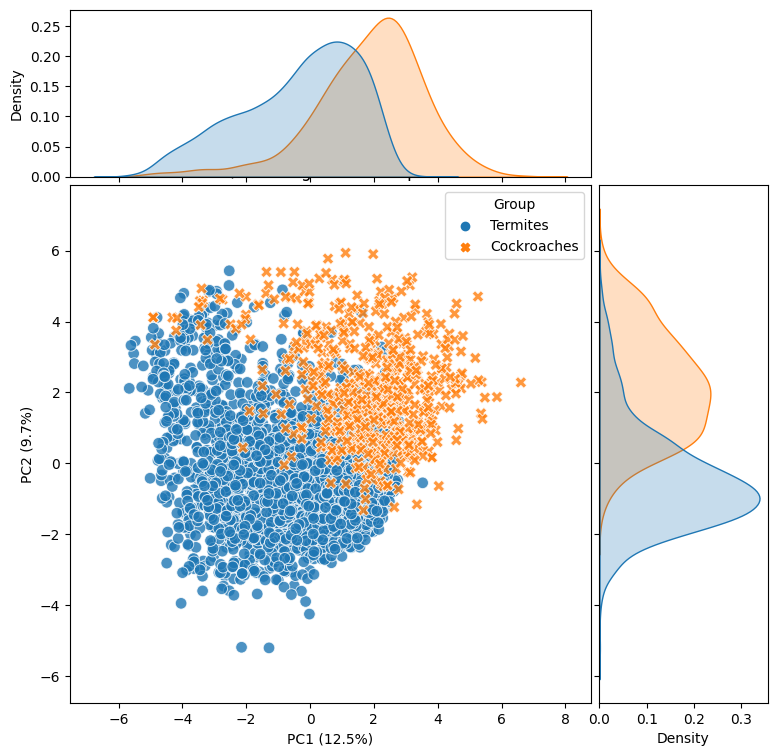

In [129]:
plot_pca_with_density(
    plus_pca_df,
    plus_explained,
    title="PCA of T/C-ending codons on plus strand"
)

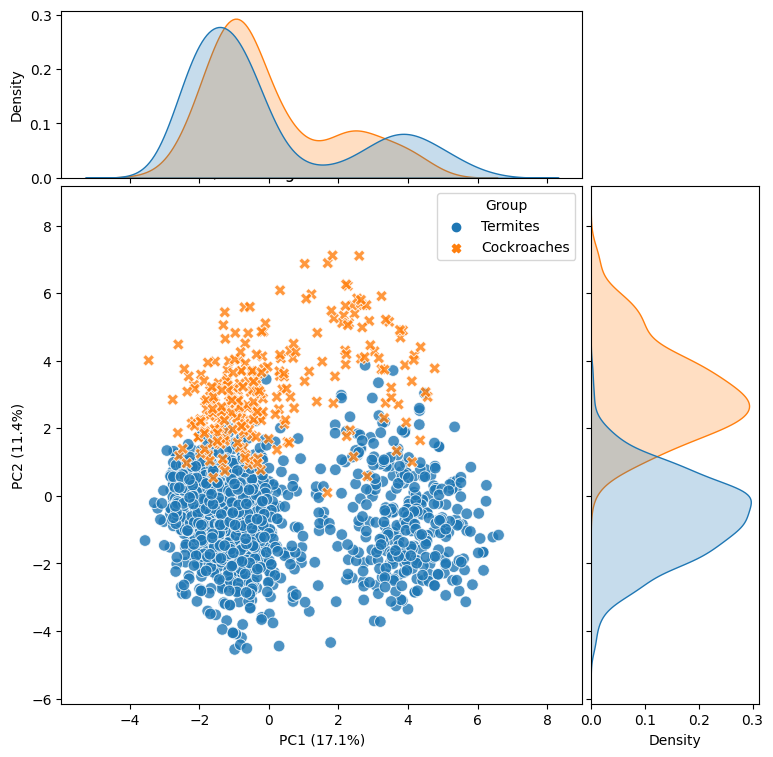

In [131]:
plot_pca_with_density(
    minus_pca_df,
    minus_explained,
    title="PCA of A/G-ending codons on minus strand"
)

In [132]:
plus_loadings.sort_values("PC1_loading", ascending=False).head(15)

,PC1_loading,PC2_loading
GGT,0.268486,0.033091
GCT,0.235526,0.030699
CAT,0.199169,0.052575
GTT,0.181685,-0.033134
AGT,0.158369,0.164177
GAT,0.149521,-0.014057
TCT,0.136398,0.164914
CTT,0.132946,0.016001
TAT,0.131189,0.181793
ACT,0.105360,0.093767


In [133]:
minus_loadings.sort_values("PC1_loading", ascending=False).head(15)

,PC1_loading,PC2_loading
AGA,0.389120,0.006867
TTG,0.362817,-0.160008
TAA,0.355715,0.091199
TTA,0.305552,0.150005
CAA,0.258621,0.159380
ATG,0.236347,-0.117735
GAG,0.178125,-0.304960
TGG,0.127920,-0.295013
ATA,0.114296,0.260542
AAG,0.084734,-0.142099


## тест по парам XXT/XXC и XXA/XXG

Для plus-цепи мы хотим проверять: XXC / (XXT + XXC)

Для minus-цепи: XXG / (XXA + XXG)

In [134]:
def make_pair_ratios_from_wide(df, endings, numerator_ending, meta_cols=META_COLS + ["Group"]):
    """
    Для plus:
        endings=("T", "C"), numerator_ending="C"
        считает XXC / (XXT + XXC)

    Для minus:
        endings=("A", "G"), numerator_ending="G"
        считает XXG / (XXA + XXG)
    """

    codon_cols = [
        col for col in df.columns
        if col not in meta_cols
    ]

    results = []

    # корни кодонов: первые две буквы
    roots = sorted(set([codon[:2] for codon in codon_cols]))

    for root in roots:
        codon_1 = root + endings[0]
        codon_2 = root + endings[1]
        numerator_codon = root + numerator_ending

        if codon_1 not in df.columns or codon_2 not in df.columns:
            continue

        temp = df[meta_cols].copy()

        denominator = df[codon_1] + df[codon_2]

        temp["pair_ratio"] = np.where(
            denominator > 0,
            df[numerator_codon] / denominator,
            np.nan
        )

        temp["codon_pair"] = codon_1 + "/" + codon_2
        temp["numerator_codon"] = numerator_codon

        results.append(temp)

    out = pd.concat(results, ignore_index=True)
    out = out.dropna(subset=["pair_ratio"])

    return out

In [135]:
plus_pair_ratios = make_pair_ratios_from_wide(
    plus_for_pca,
    endings=("T", "C"),
    numerator_ending="C"
)

In [136]:
minus_pair_ratios = make_pair_ratios_from_wide(
    minus_for_pca,
    endings=("A", "G"),
    numerator_ending="G"
)

In [137]:
plus_pair_ratios

,Species,Species_name,Group,pair_ratio,codon_pair,numerator_codon
0,Termite,Acanthotermes_acanthothorax_187525,Termites,0.888889,AAT/AAC,AAC
1,Termite,Acanthotermes_acanthothorax_187525,Termites,0.571429,AAT/AAC,AAC
2,Termite,Acanthotermes_acanthothorax_187525,Termites,0.850000,AAT/AAC,AAC
3,Termite,Acanthotermes_acanthothorax_187525,Termites,0.818182,AAT/AAC,AAC
4,Termite,Acanthotermes_acanthothorax_187525,Termites,0.625000,AAT/AAC,AAC
...,...,...,...,...,...,...
57163,Cockroach,Pseudoglomeris_magnifica_2813672,Cockroaches,0.200000,TTT/TTC,TTC
57164,Cockroach,Pseudoglomeris_magnifica_2813672,Cockroaches,0.266667,TTT/TTC,TTC
57165,Cockroach,Pseudoglomeris_magnifica_2813672,Cockroaches,0.300000,TTT/TTC,TTC
57166,Cockroach,Pseudoglomeris_magnifica_2813672,Cockroaches,0.545455,TTT/TTC,TTC


Для плюс
Если значение близко к 1, вид чаще использует TTC.

Если близко к 0, чаще использует TTT.

Для минус - если значение близко к 1, вид чаще использует G-ending кодон.

## Модель сразу по всем codon pairs

In [138]:
def run_global_pair_model_no_family(pair_ratios):
    df = pair_ratios.copy()

    eps = 1e-6

    df["logit_ratio"] = logit(
        np.clip(df["pair_ratio"], eps, 1 - eps)
    )

    model = smf.ols(
        "logit_ratio ~ Group + C(codon_pair)",
        data=df
    ).fit()

    return model

#logit_ratio зависит от:
#1. Group — термиты или тараканы
#2. codon_pair — какая именно пара кодонов сравнивается

In [139]:
plus_global_model_no_family = run_global_pair_model_no_family(
    plus_pair_ratios
)

print(plus_global_model_no_family.summary())

                            OLS Regression Results                            
Dep. Variable:            logit_ratio   R-squared:                       0.108
Model:                            OLS   Adj. R-squared:                  0.107
Method:                 Least Squares   F-statistic:                     368.1
Date:                Fri, 05 Jun 2026   Prob (F-statistic):               0.00
Time:                        16:01:27   Log-Likelihood:            -1.6836e+05
No. Observations:               48867   AIC:                         3.368e+05
Df Residuals:                   48850   BIC:                         3.369e+05
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [140]:
minus_global_model_no_family = run_global_pair_model_no_family(
    minus_pair_ratios
)

print(minus_global_model_no_family.summary())

                            OLS Regression Results                            
Dep. Variable:            logit_ratio   R-squared:                       0.190
Model:                            OLS   Adj. R-squared:                  0.190
Method:                 Least Squares   F-statistic:                     327.8
Date:                Fri, 05 Jun 2026   Prob (F-statistic):               0.00
Time:                        16:01:28   Log-Likelihood:                -77119.
No. Observations:               22358   AIC:                         1.543e+05
Df Residuals:                   22341   BIC:                         1.544e+05
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

## Расшифровка

Главный коэффициент — Group[T.Termites].
plus
Group[T.Termites] = 2.7298
p < 0.001

minus
Group[T.Termites] = 5.9805
p < 0.001

При одинаковой codon_pair у термитов logit-ratio выше, чем у тараканов.

Для plus это значит:

У термитов выше относительное использование C-ending кодонов в парах XXT/XXC.

Для minus это значит:

У термитов выше относительное использование G-ending кодонов в парах XXA/XXG.

У термитов odds использования C-ending кодона относительно T-ending кодона примерно в 15.3 раза выше, чем у тараканов, после учёта различий между codon pairs.
На plus-цепи термиты значительно чаще используют C-ending кодоны в парах XXT/XXC, чем тараканы.

У термитов odds использования G-ending кодона относительно A-ending кодона примерно в 396 раз выше, чем у тараканов, после учёта различий между codon pairs.
На minus-цепи термиты намного чаще используют G-ending кодоны в парах XXA/XXG, чем тараканы.

plus-модель объясняет около 12.7% вариации logit_ratio

minus-модель объясняет около 19.0% вариации logit_ratio

In [154]:
codon_table = pd.read_csv('../data/codontable_midori_Blattodea.csv', index_col=0)
codon_table.loc[codon_table['Workers'] == 1.0, 'Workers'] = 'Termite'
codon_table.loc[codon_table['Workers'] == 0.0, 'Workers'] = 'Termite'
codon_table['Workers'] = codon_table['Workers'].fillna('Cockroach')
codon_table = codon_table.rename(columns={'Workers':'Species'})

plus_genes = ['A6', 'A8', 'CO1', 'CO2', 'CO3', 'Cytb', 'ND2', 'ND3', 'ND6']
minus_genes = ['ND5', 'ND4', 'ND4L', 'ND1']

plus_codon_table = codon_table[codon_table['Gene_name'].isin(plus_genes)]
minus_codon_table = codon_table[codon_table['Gene_name'].isin(minus_genes)]

termite_plus = plus_codon_table[plus_codon_table['Species'] == 'Termite']
termite_minus = minus_codon_table[minus_codon_table['Species'] == 'Termite']

cockroach_plus = plus_codon_table[plus_codon_table['Species'] == 'Cockroach']
cockroach_minus = minus_codon_table[minus_codon_table['Species'] == 'Cockroach']

cockroach_plus = cockroach_plus[['Species', 'Species_name', 'Gene_name'] + list(cockroach_plus.columns[30:])]
termite_plus = termite_plus[['Species', 'Species_name', 'Gene_name'] + list(termite_plus.columns[30:])]
cockroach_minus = cockroach_minus[['Species', 'Species_name', 'Gene_name'] + list(cockroach_minus.columns[30:])]
termite_minus = termite_minus[['Species', 'Species_name', 'Gene_name'] + list(termite_minus.columns[30:])]

In [155]:
def prepare_wide_codon_table(df, group_name):
    out = df.copy()
    out["Group"] = group_name
    return out

In [156]:
minus_gene_df = pd.concat(
    [
        prepare_wide_codon_table(termite_minus, "Termites"),
        prepare_wide_codon_table(cockroach_minus, "Cockroaches")
    ],
    ignore_index=True
)

In [157]:
plus_gene_df = pd.concat(
    [
        prepare_wide_codon_table(termite_plus, "Termites"),
        prepare_wide_codon_table(cockroach_plus, "Cockroaches")
    ],
    ignore_index=True
)

In [158]:
def get_codon_columns(df):
    codon_cols = [
        col for col in df.columns
        if isinstance(col, str)
        and len(col) == 3
        and set(col).issubset(set("ATGC"))
    ]
    return codon_cols

In [159]:
minus_codon_cols = get_codon_columns(minus_gene_df)
plus_codon_cols = get_codon_columns(plus_gene_df)

print(len(minus_codon_cols), minus_codon_cols[:10])
print(len(plus_codon_cols), plus_codon_cols[:10])

64 ['TTT', 'TTC', 'TTA', 'TTG', 'TCT', 'TCC', 'TCA', 'TCG', 'TAT', 'TAC']
64 ['TTT', 'TTC', 'TTA', 'TTG', 'TCT', 'TCC', 'TCA', 'TCG', 'TAT', 'TAC']


In [160]:
def clr_transform_from_counts_or_fractions(X, pseudocount=1e-6):
    """
    X может быть counts или fractions.
    Сначала нормируем строки до суммы 1, потом делаем CLR.
    """
    X = X.copy().astype(float)

    row_sums = X.sum(axis=1)

    X = X.div(row_sums, axis=0)

    X = X + pseudocount

    log_X = np.log(X)
    clr_X = log_X.sub(log_X.mean(axis=1), axis=0)

    return clr_X

In [161]:
def make_gene_level_pca(df, endings=("A", "G")):
    df = df.copy()

    codon_cols = get_codon_columns(df)

    selected_codon_cols = [
        col for col in codon_cols
        if col[-1] in endings
    ]

    meta_cols = ["Species", "Species_name", "Gene_name", "Group"]

    X = df[selected_codon_cols].copy()

    X_clr = clr_transform_from_counts_or_fractions(X)

    X_scaled = StandardScaler().fit_transform(X_clr)

    pca = PCA(n_components=2)
    coords = pca.fit_transform(X_scaled)

    pca_df = df[meta_cols].copy()
    pca_df["PC1"] = coords[:, 0]
    pca_df["PC2"] = coords[:, 1]

    explained = pca.explained_variance_ratio_ * 100

    wide_used = df[selected_codon_cols].copy()

    return pca_df, pca, explained, wide_used, X_clr

In [162]:
minus_gene_pca_df, minus_gene_pca, minus_gene_explained, minus_gene_wide, minus_gene_clr = make_gene_level_pca(
    minus_gene_df,
    endings=("A", "G")
)

In [163]:
plus_gene_pca_df, plus_gene_pca, plus_gene_explained, plus_gene_wide, plus_gene_clr = make_gene_level_pca(
    plus_gene_df,
    endings=("T", "C")
)

In [164]:
def plot_pca_by_gene(pca_df, explained, title):
    plt.figure(figsize=(10, 7))

    sns.scatterplot(
        data=pca_df,
        x="PC1",
        y="PC2",
        hue="Gene_name",
        style="Group",
        s=70,
        alpha=0.8
    )

    plt.xlabel(f"PC1 ({explained[0]:.1f}%)")
    plt.ylabel(f"PC2 ({explained[1]:.1f}%)")
    plt.title(title)

    plt.legend(
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        borderaxespad=0
    )

    plt.tight_layout()
    plt.show()

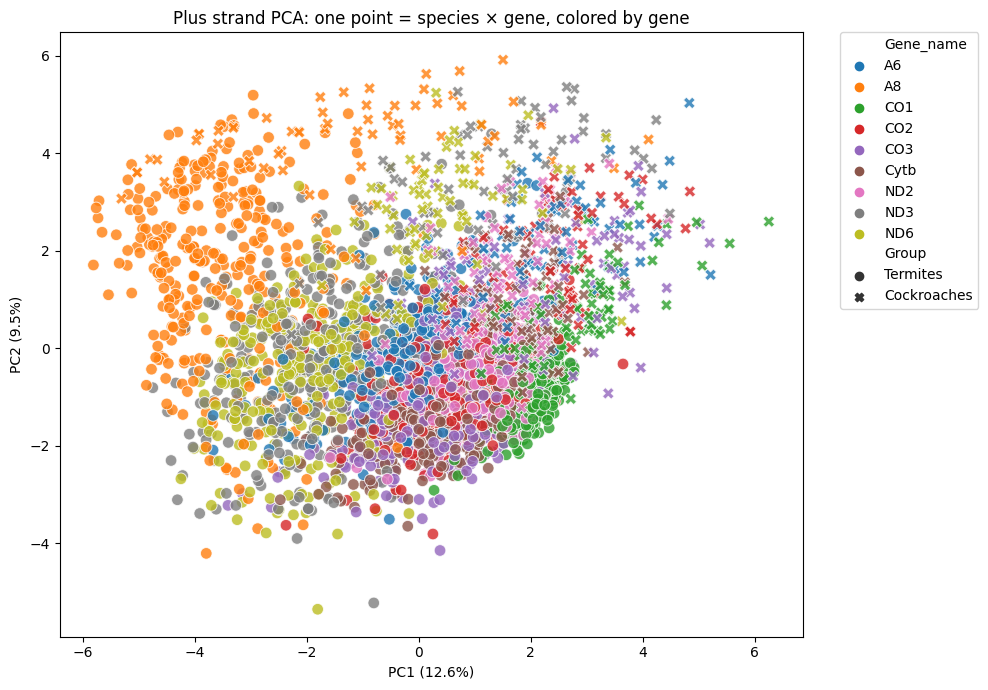

In [165]:
plot_pca_by_gene(
    plus_gene_pca_df,
    plus_gene_explained,
    title="Plus strand PCA: one point = species × gene, colored by gene"
)

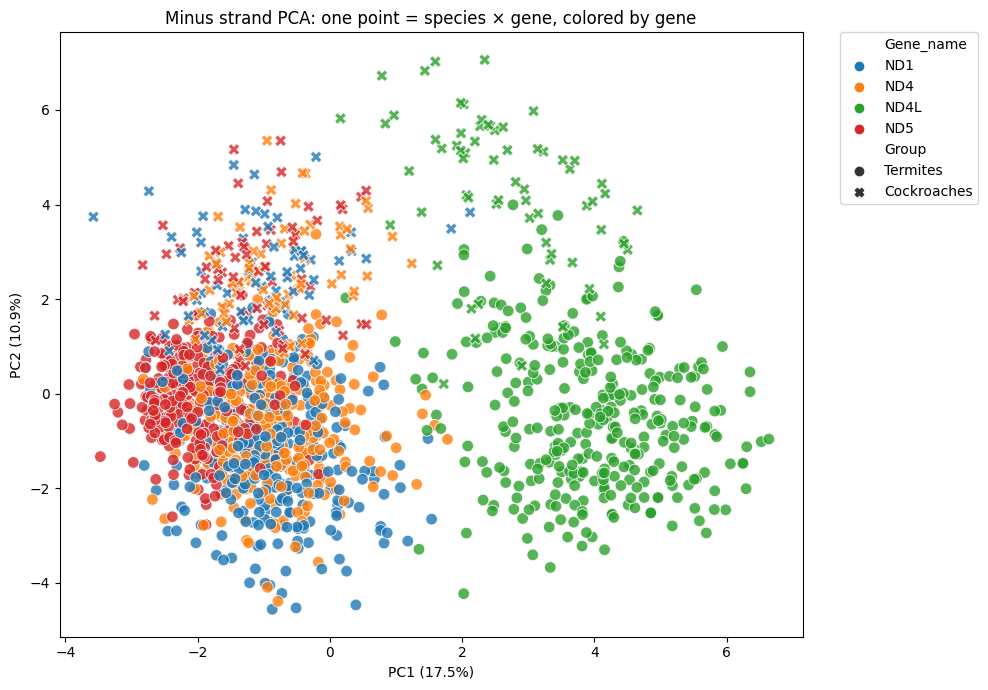

In [166]:
plot_pca_by_gene(
    minus_gene_pca_df,
    minus_gene_explained,
    title="Minus strand PCA: one point = species × gene, colored by gene"
)

In [28]:
codon_table = pd.read_csv('../data/codontable_midori_Blattodea.csv', index_col=0)
codon_table.loc[codon_table['Workers'] == 1.0, 'Workers'] = 'Termite'
codon_table.loc[codon_table['Workers'] == 0.0, 'Workers'] = 'Termite'
codon_table['Workers'] = codon_table['Workers'].fillna('Cockroach')
codon_table = codon_table.rename(columns={'Workers':'Species'})

plus_genes = ['A6', 'A8', 'CO1', 'CO2', 'CO3', 'Cytb', 'ND2', 'ND3', 'ND6']
minus_genes = ['ND5', 'ND4', 'ND4L', 'ND1']

plus_codon_table = codon_table[codon_table['Gene_name'].isin(plus_genes)]
minus_codon_table = codon_table[codon_table['Gene_name'].isin(minus_genes)]

termite_plus = plus_codon_table[plus_codon_table['Species'] == 'Termite']
termite_minus = minus_codon_table[minus_codon_table['Species'] == 'Termite']

cockroach_plus = plus_codon_table[plus_codon_table['Species'] == 'Cockroach']
cockroach_minus = minus_codon_table[minus_codon_table['Species'] == 'Cockroach']

cockroach_plus = cockroach_plus[['Species', 'Species_name'] + list(cockroach_plus.columns[30:])]
termite_plus = termite_plus[['Species', 'Species_name'] + list(termite_plus.columns[30:])]
cockroach_minus = cockroach_minus[['Species', 'Species_name'] + list(cockroach_minus.columns[30:])]
termite_minus = termite_minus[['Species', 'Species_name'] + list(termite_minus.columns[30:])]

In [29]:
def prepare_wide_codon_table(df, group_name):
    out = df.copy()
    out["Group"] = group_name
    return out

In [30]:
minus_gene_df = pd.concat(
    [
        prepare_wide_codon_table(termite_minus, "Termites"),
        prepare_wide_codon_table(cockroach_minus, "Cockroaches")
    ],
    ignore_index=True
)

plus_gene_df = pd.concat(
    [
        prepare_wide_codon_table(termite_plus, "Termites"),
        prepare_wide_codon_table(cockroach_plus, "Cockroaches")
    ],
    ignore_index=True
)

In [31]:
minus_gene_df

,Species,Species_name,TTT,TTC,TTA,TTG,TCT,TCC,TCA,TCG,...,GAC,GAA,GAG,GGT,GGC,GGA,GGG,TAA,TAG,Group
0,Termite,Acanthotermes_acanthothorax_187525,43,5,7,33,16,0,2,1,...,0,0,10,13,1,2,6,0,1,Termites
1,Termite,Acanthotermes_acanthothorax_187525,48,4,17,47,26,0,2,1,...,0,1,7,21,4,1,5,0,1,Termites
2,Termite,Acanthotermes_acanthothorax_187525,12,0,1,11,6,1,1,0,...,0,0,2,5,0,0,0,1,0,Termites
3,Termite,Acanthotermes_acanthothorax_187525,65,4,14,52,41,4,1,1,...,1,4,5,25,5,2,16,0,0,Termites
4,Termite,Acholotermes_chirotus_1934430,39,7,13,26,15,1,3,2,...,0,4,6,14,3,1,5,0,1,Termites
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1583,Cockroach,Protagonista_lugubris_1844480,64,0,60,20,24,0,9,2,...,2,7,2,17,3,15,3,1,0,Cockroaches
1584,Cockroach,Pseudoglomeris_magnifica_2813672,32,0,38,12,12,0,4,1,...,0,9,2,2,1,10,4,0,1,Cockroaches
1585,Cockroach,Pseudoglomeris_magnifica_2813672,38,1,76,13,12,1,7,2,...,0,8,2,15,1,13,3,1,0,Cockroaches
1586,Cockroach,Pseudoglomeris_magnifica_2813672,15,0,13,4,2,0,3,0,...,0,2,1,2,1,1,1,1,0,Cockroaches


In [32]:
def get_codon_columns(df):
    return [
        col for col in df.columns
        if (
            isinstance(col, str)
            and len(col) == 3
            and set(col.upper()).issubset({"A", "T", "G", "C"})
        )
    ]

In [33]:
def normalize_codon_pairs_for_pca(df, endings):
    codon_cols = get_codon_columns(df)

    metadata_cols = [
        col for col in df.columns
        if col not in codon_cols
    ]

    result = df[metadata_cols].copy()

    codon_roots = sorted({
        codon[:2]
        for codon in codon_cols
        if codon[-1] in endings
    })

    for root in codon_roots:
        codon_1 = root + endings[0]
        codon_2 = root + endings[1]

        if codon_1 not in df.columns or codon_2 not in df.columns:
            continue

        denominator = df[codon_1] + df[codon_2]

        result[codon_1] = np.where(
            denominator > 0,
            df[codon_1] / denominator,
            np.nan
        )

        result[codon_2] = np.where(
            denominator > 0,
            df[codon_2] / denominator,
            np.nan
        )

    return result

In [36]:
def make_pca_from_normalized(df, fill_value=0.5, n_components=2):
    """
    PCA для нормализованной таблицы кодонов.

    Parameters
    ----------
    df : pd.DataFrame
        Таблица вида plus_for_pca_normalized / minus_for_pca_normalized
    fill_value : float
        Чем заменять NaN после нормализации внутри пары.
        0.5 = нейтральное значение.
    n_components : int
        Число главных компонент.

    Returns
    -------
    pca_df : pd.DataFrame
        Исходные метаданные + PC1, PC2
    pca : fitted PCA object
    explained : np.ndarray
        Объяснённая дисперсия (%)
    loadings : pd.DataFrame
        Вклады кодонов в PC1 и PC2
    X_used : pd.DataFrame
        Матрица признаков, использованная для PCA
    """
    codon_cols = get_codon_columns(df)

    metadata_cols = [col for col in df.columns if col not in codon_cols]

    X = df[codon_cols].copy()

    # NaN -> нейтральное значение
    X = X.fillna(fill_value)

    # Убираем колонки без вариации
    variable_cols = X.columns[X.var() > 0]
    X = X[variable_cols]

    # Стандартизация
    X_scaled = StandardScaler().fit_transform(X)

    # PCA
    pca = PCA(n_components=n_components)
    coords = pca.fit_transform(X_scaled)

    pca_df = df[metadata_cols].copy()
    pca_df["PC1"] = coords[:, 0]
    pca_df["PC2"] = coords[:, 1]

    explained = pca.explained_variance_ratio_ * 100

    loadings = pd.DataFrame(
        pca.components_.T,
        index=X.columns,
        columns=["PC1_loading", "PC2_loading"]
    )

    return pca_df, pca, explained, loadings, X

In [34]:
plus_for_pca_normalized = normalize_codon_pairs_for_pca(
    plus_gene_df,
    endings=("T", "C")
)

minus_for_pca_normalized = normalize_codon_pairs_for_pca(
    minus_gene_df,
    endings=("A", "G")
)

In [37]:
plus_pca_df, plus_pca, plus_explained, plus_loadings, plus_X = make_pca_from_normalized(
    plus_for_pca_normalized,
    fill_value=0.5
)

minus_pca_df, minus_pca, minus_explained, minus_loadings, minus_X = make_pca_from_normalized(
    minus_for_pca_normalized,
    fill_value=0.5
)

In [77]:
def plot_pca_with_density(pca_df, explained, group_col="Species", title="PCA with densities", file_name="codon_usage_pca"):
    fig = plt.figure(figsize=(9, 9))

    gs = GridSpec(4, 4, figure=fig, hspace=0.05, wspace=0.05)

    ax_scatter = fig.add_subplot(gs[1:4, 0:3])
    ax_top = fig.add_subplot(gs[0, 0:3], sharex=ax_scatter)
    ax_right = fig.add_subplot(gs[1:4, 3], sharey=ax_scatter)

    # Scatter
    sns.scatterplot(
        data=pca_df,
        x="PC1",
        y="PC2",
        hue=group_col,
        style=group_col,
        s=70,
        alpha=0.8,
        ax=ax_scatter
    )

    # Density PC1
    sns.kdeplot(
        data=pca_df,
        x="PC1",
        hue=group_col,
        common_norm=False,
        fill=True,
        alpha=0.25,
        ax=ax_top,
        legend=False
    )

    # Density PC2
    sns.kdeplot(
        data=pca_df,
        y="PC2",
        hue=group_col,
        common_norm=False,
        fill=True,
        alpha=0.25,
        ax=ax_right,
        legend=False
    )

    ax_scatter.set_xlabel(f"PC1 ({explained[0]:.1f}%)")
    ax_scatter.set_ylabel(f"PC2 ({explained[1]:.1f}%)")
    ax_scatter.set_title(title)

    ax_top.set_ylabel("Density")
    ax_top.tick_params(axis="x", labelbottom=False)

    ax_right.set_xlabel("Density")
    ax_right.tick_params(axis="y", labelleft=False)

    plt.tight_layout()
    plt.savefig('../figures/{}.pdf'.format(file_name))
    plt.show()
    plt.close()

C:\Users\voron\AppData\Local\Temp\ipykernel_90748\1646145597.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


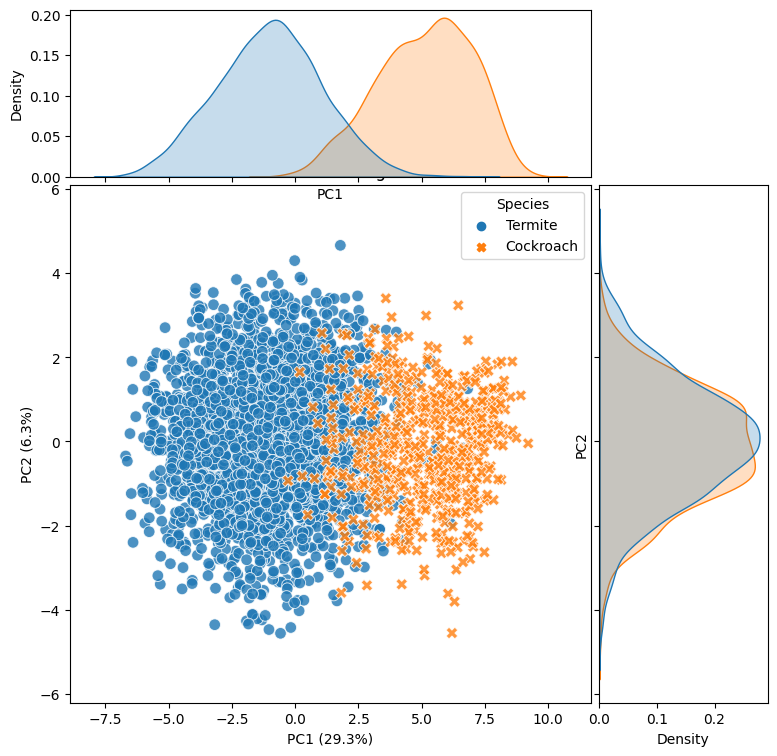

In [78]:
plot_pca_with_density(
    plus_pca_df,
    plus_explained,
    group_col="Species",
    title="Plus strand PCA with marginal densities", 
    file_name = "plus_pca_codons"
)

C:\Users\voron\AppData\Local\Temp\ipykernel_90748\1646145597.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


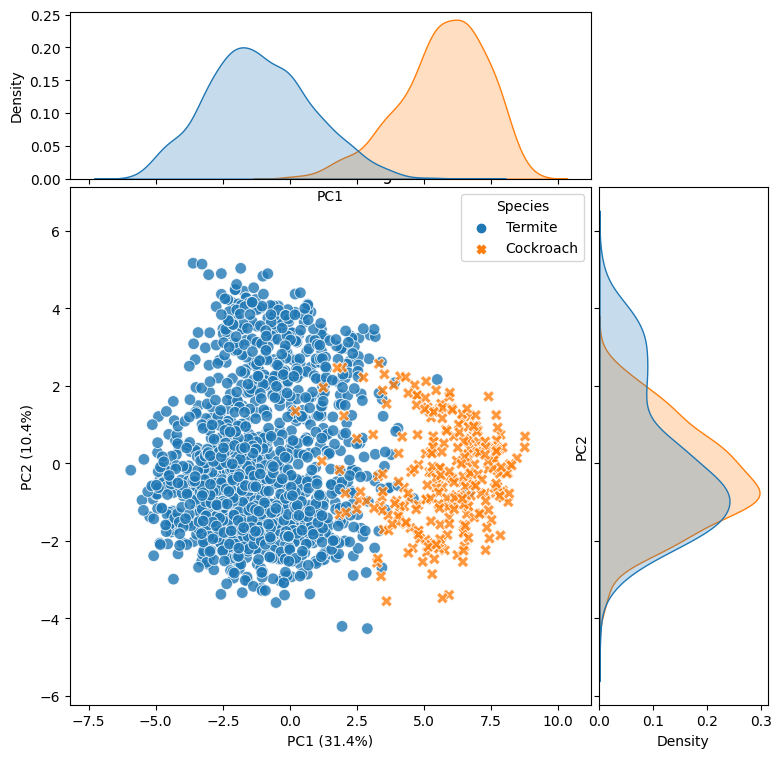

In [79]:
plot_pca_with_density(
    minus_pca_df,
    minus_explained,
    group_col="Species",
    title="Minus strand PCA with marginal densities", 
    file_name = "minus_pca_codons"
)

In [41]:
plus_loadings.sort_values("PC1_loading", ascending=False).head(15)

,PC1_loading,PC2_loading
ATT,0.255789,0.008788
AAT,0.237899,-0.082423
TTT,0.236991,-0.041624
TAT,0.222254,-0.060760
ACT,0.198396,0.048207
CAT,0.192801,-0.076654
GAT,0.169033,0.032799
GCT,0.160281,-0.100677
GTT,0.159362,0.188586
AGT,0.146961,0.123188


In [42]:
minus_loadings.sort_values("PC1_loading", ascending=False).head(15)

,PC1_loading,PC2_loading
TTA,0.264780,-0.135557
ATA,0.256863,0.017361
GAA,0.226610,-0.096080
GGA,0.206667,-0.000405
TGA,0.200270,-0.086372
AAA,0.188184,-0.014753
GTA,0.169125,-0.163946
AGA,0.168688,0.341182
CAA,0.158464,0.337815
CTA,0.146058,-0.110578


## тест по парам XXT/XXC и XXA/XXG

In [43]:
def make_pair_ratios_from_wide(df, endings, numerator_ending, meta_cols=META_COLS + ["Group"]):
    """
    Для plus:
        endings=("T", "C"), numerator_ending="C"
        считает XXC / (XXT + XXC)

    Для minus:
        endings=("A", "G"), numerator_ending="G"
        считает XXG / (XXA + XXG)
    """

    codon_cols = [
        col for col in df.columns
        if col not in meta_cols
    ]

    results = []

    # корни кодонов: первые две буквы
    roots = sorted(set([codon[:2] for codon in codon_cols]))

    for root in roots:
        codon_1 = root + endings[0]
        codon_2 = root + endings[1]
        numerator_codon = root + numerator_ending

        if codon_1 not in df.columns or codon_2 not in df.columns:
            continue

        temp = df[meta_cols].copy()

        denominator = df[codon_1] + df[codon_2]

        temp["pair_ratio"] = np.where(
            denominator > 0,
            df[numerator_codon] / denominator,
            np.nan
        )

        temp["codon_pair"] = codon_1 + "/" + codon_2
        temp["numerator_codon"] = numerator_codon

        results.append(temp)

    out = pd.concat(results, ignore_index=True)
    out = out.dropna(subset=["pair_ratio"])

    return out

In [48]:
plus_pair_ratios = make_pair_ratios_from_wide(
    plus_for_pca_normalized,
    endings=("T", "C"),
    numerator_ending="C"
)

minus_pair_ratios = make_pair_ratios_from_wide(
    minus_for_pca_normalized,
    endings=("A", "G"),
    numerator_ending="G"
)

In [49]:
def run_global_pair_model_no_family(pair_ratios):
    df = pair_ratios.copy()

    eps = 1e-6

    df["logit_ratio"] = logit(
        np.clip(df["pair_ratio"], eps, 1 - eps)
    )

    model = smf.ols(
        "logit_ratio ~ Group + C(codon_pair)",
        data=df
    ).fit()

    return model

#logit_ratio зависит от:
#1. Group — термиты или тараканы
#2. codon_pair — какая именно пара кодонов сравнивается

In [50]:
plus_global_model_no_family = run_global_pair_model_no_family(
    plus_pair_ratios
)

print(plus_global_model_no_family.summary())

                            OLS Regression Results                            
Dep. Variable:            logit_ratio   R-squared:                       0.108
Model:                            OLS   Adj. R-squared:                  0.107
Method:                 Least Squares   F-statistic:                     368.1
Date:                Tue, 16 Jun 2026   Prob (F-statistic):               0.00
Time:                        15:18:48   Log-Likelihood:            -1.6836e+05
No. Observations:               48867   AIC:                         3.368e+05
Df Residuals:                   48850   BIC:                         3.369e+05
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

### Модель отвечает на вопрос:

Есть ли общий направленный сдвиг в сторону C-ending кодонов у термитов?

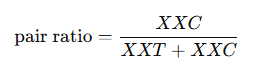

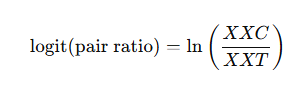

Group[T.Termites] = 5.7491
SE = 0.092
t = 62.653
p < 0.001
95% CI: 5.569–5.929
При сравнении одной и той же пары кодонов log-отношение C-ending/T-ending у термитов в среднем на 5.749 выше, чем у тараканов.

После учёта различий между отдельными парами кодонов отношение шансов использования C-ending кодона вместо соответствующего T-ending кодона у термитов примерно в 314 раз выше, чем у тараканов. Это указывает на очень выраженное обогащение C-ending кодонов у термитов.

In [51]:
minus_global_model_no_family = run_global_pair_model_no_family(
    minus_pair_ratios
)

print(minus_global_model_no_family.summary())

                            OLS Regression Results                            
Dep. Variable:            logit_ratio   R-squared:                       0.190
Model:                            OLS   Adj. R-squared:                  0.190
Method:                 Least Squares   F-statistic:                     327.8
Date:                Tue, 16 Jun 2026   Prob (F-statistic):               0.00
Time:                        15:19:02   Log-Likelihood:                -77119.
No. Observations:               22358   AIC:                         1.543e+05
Df Residuals:                   22341   BIC:                         1.544e+05
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

При сравнении одной и той же пары кодонов log-отношение G-ending/A-ending у термитов в среднем на 5.981 выше, чем у тараканов.

После учёта различий между codon pairs отношение шансов использования G-ending кодона вместо соответствующего A-ending кодона у термитов примерно в 396 раз выше, чем у тараканов.

Это указывает на очень сильный общий сдвиг в сторону G-ending кодонов у термитов.

После учёта различий между отдельными codon pairs у термитов было выявлено значительное обогащение C-ending кодонов на plus-цепи и G-ending кодонов на minus-цепи. Комплементарный характер этих сдвигов согласуется с гипотезой о направленном влиянии strand-specific mutational bias на использование синонимичных кодонов.

## Просто density plot

In [52]:
codon_table = pd.read_csv('../data/codontable_midori_Blattodea.csv', index_col=0)
codon_table.loc[codon_table['Workers'] == 1.0, 'Workers'] = 'Termite'
codon_table.loc[codon_table['Workers'] == 0.0, 'Workers'] = 'Termite'
codon_table['Workers'] = codon_table['Workers'].fillna('Cockroach')
codon_table = codon_table.rename(columns={'Workers':'Species'})

plus_genes = ['A6', 'A8', 'CO1', 'CO2', 'CO3', 'Cytb', 'ND2', 'ND3', 'ND6']
minus_genes = ['ND5', 'ND4', 'ND4L', 'ND1']

plus_codon_table = codon_table[codon_table['Gene_name'].isin(plus_genes)]
minus_codon_table = codon_table[codon_table['Gene_name'].isin(minus_genes)]

termite_plus = plus_codon_table[plus_codon_table['Species'] == 'Termite']
termite_minus = minus_codon_table[minus_codon_table['Species'] == 'Termite']

cockroach_plus = plus_codon_table[plus_codon_table['Species'] == 'Cockroach']
cockroach_minus = minus_codon_table[minus_codon_table['Species'] == 'Cockroach']

cockroach_plus = cockroach_plus[['Species', 'Species_name'] + list(cockroach_plus.columns[30:])]
termite_plus = termite_plus[['Species', 'Species_name'] + list(termite_plus.columns[30:])]
cockroach_minus = cockroach_minus[['Species', 'Species_name'] + list(cockroach_minus.columns[30:])]
termite_minus = termite_minus[['Species', 'Species_name'] + list(termite_minus.columns[30:])]

In [53]:
def prepare_wide_codon_table(df, group_name):
    out = df.copy()
    out["Group"] = group_name
    return out

In [54]:
minus_gene_df = pd.concat(
    [
        prepare_wide_codon_table(termite_minus, "Termites"),
        prepare_wide_codon_table(cockroach_minus, "Cockroaches")
    ],
    ignore_index=True
)

plus_gene_df = pd.concat(
    [
        prepare_wide_codon_table(termite_plus, "Termites"),
        prepare_wide_codon_table(cockroach_plus, "Cockroaches")
    ],
    ignore_index=True
)

In [56]:
def get_codon_columns(df):
    return [
        col for col in df.columns
        if (
            isinstance(col, str)
            and len(col) == 3
            and set(col.upper()).issubset({"A", "T", "G", "C"})
        )
    ]

In [61]:
def add_median_ending_ratio_filtered(df, numerator_ending, denominator_ending):
    out = df.copy()

    codon_cols = get_codon_columns(out)

    numerator_cols = [col for col in codon_cols if col.endswith(numerator_ending)]
    denominator_cols = [col for col in codon_cols if col.endswith(denominator_ending)]

    out[f"median_{numerator_ending}"] = out[numerator_cols].median(axis=1)
    out[f"median_{denominator_ending}"] = out[denominator_cols].median(axis=1)

    # исключаем строки, где хотя бы одна медиана равна 0
    out = out[
        (out[f"median_{numerator_ending}"] > 0) &
        (out[f"median_{denominator_ending}"] > 0)
    ].copy()

    out[f"{numerator_ending}{denominator_ending}_median_ratio"] = (
        out[f"median_{numerator_ending}"] / out[f"median_{denominator_ending}"]
    )

    return out

In [80]:
def plot_density_ratio(df, ratio_col, group_col="Group", title="Density plot", file_name="density_plot"):
    palette = {
    'Cockroaches': '#8B5A2B',
    "Termites" : "#D98C1A"
    }
    plt.figure(figsize=(8, 6))

    sns.kdeplot(
        data=df,
        x=ratio_col,
        hue=group_col,
        fill=True,
        common_norm=False,
        alpha=0.3,
        palette=palette
    )

    plt.title(title)
    plt.xlabel(ratio_col)
    plt.ylabel("Density")
    plt.tight_layout()
    plt.savefig('../figures/{}.pdf'.format(file_name))
    plt.show()
    plt.close()

In [81]:
plus_median_df = add_median_ending_ratio_filtered(
    plus_gene_df,
    numerator_ending="C",
    denominator_ending="T"
)

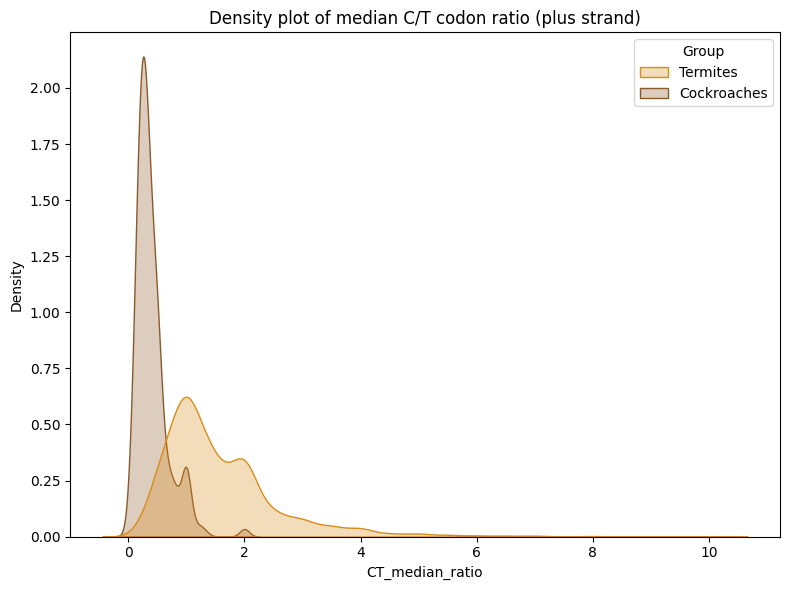

In [82]:
plot_density_ratio(
    plus_median_df,
    ratio_col="CT_median_ratio",
    group_col="Group",
    title="Density plot of median C/T codon ratio (plus strand)",
    file_name = "density_plus"
)

In [83]:
minus_median_df = add_median_ending_ratio_filtered(
    minus_gene_df,
    numerator_ending="G",
    denominator_ending="A"
)

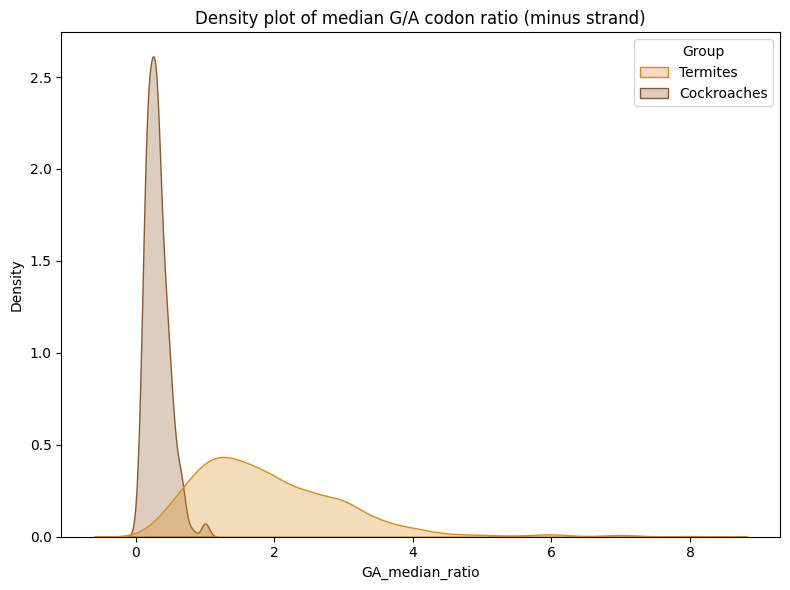

In [84]:
plot_density_ratio(
    minus_median_df,
    ratio_col="GA_median_ratio",
    group_col="Group",
    title="Density plot of median G/A codon ratio (minus strand)",
    file_name = "density_minus"
)